In [71]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


#  **Setup & Imports**

In [72]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import wandb

sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

# **Dataset Description**

##  Load Data

In [73]:
DATA_PATH   = "/kaggle/input/competitions/smart-mcq-solver-challenge"
OPTION_COLS = ["A", "B", "C", "D", "E"]


In [74]:
train = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
test  = pd.read_csv(os.path.join(DATA_PATH, "test.csv"))

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head(5)


Train shape: (2000, 8)
Test shape : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


# **EDA & Preprocessing**

## Basic Info

In [75]:
print("TRAIN INFO:")
print(train.info())


TRAIN INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB
None


## Missing Values

In [76]:
print("MISSING VALUES")
print(train.isnull().sum())


MISSING VALUES
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


##  Duplicate Values

In [77]:
print("DUPLICATES:")
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate prompts      :", train['prompt'].duplicated().sum())


DUPLICATES:
Duplicate rows in train: 0
Duplicate prompts      : 242


In [78]:
# Duplicate prompts explore
dup_prompts = train[train['prompt'].duplicated(keep=False)].sort_values('prompt')
print(f"Total rows with duplicate prompts: {len(dup_prompts)}")
print(f"\nSame prompt, different answers example:")
print(dup_prompts[['prompt','answer']].head(6).to_string())

# same prompt have same ans or different?
same_answer = train.groupby('prompt')['answer'].nunique()
print(f"\nPrompts with same answer always  : {(same_answer == 1).sum()}")
print(f"Prompts with different answers   : {(same_answer > 1).sum()}")


Total rows with duplicate prompts: 454

Same prompt, different answers example:
                                                                                                         prompt answer
605                                           Choose the correct answer: What are permutation-inversion groups?      E
456                                           Choose the correct answer: What are permutation-inversion groups?      E
439                                           Choose the correct answer: What are permutation-inversion groups?      E
1464              Choose the correct answer: What are permutation-inversion groups? based on the given context.      E
42                Choose the correct answer: What are permutation-inversion groups? based on the given context.      E
484   Choose the correct answer: What are the four qualitative levels of crystallinity described by geologists?      B

Prompts with same answer always  : 1758
Prompts with different answers   : 0


##  Text Cleaning

In [79]:
def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

train['cleaned_prompt'] = train['prompt'].apply(clean_text)
test['cleaned_prompt']  = test['prompt'].apply(clean_text)

for opt in OPTION_COLS:
    train[f'cleaned_{opt}'] = train[opt].apply(clean_text)

print("Text cleaning done.")
print("\nSample cleaned prompt:")
print(train['cleaned_prompt'].iloc[0])


Text cleaning done.

Sample cleaned prompt:
pick the best possible answer what is martin heideggers view on the relationship between time and human existence among the listed options


##  Prompt Length Analysis

In [80]:
train['prompt_word_count'] = train['cleaned_prompt'].apply(lambda x: len(x.split()))
train['prompt_char_count'] = train['cleaned_prompt'].apply(len)
test['prompt_word_count']  = test['cleaned_prompt'].apply(lambda x: len(x.split()))

print("Train Prompt Word Count:")
print(train['prompt_word_count'].describe().round(2))


Train Prompt Word Count:
count    2000.00
mean       18.15
std         6.78
min         3.00
25%        14.00
50%        17.00
75%        22.00
max        51.00
Name: prompt_word_count, dtype: float64


## Option Length Comparison

In [81]:
option_lengths = {}
for opt in OPTION_COLS:
    option_lengths[opt] = train[f'cleaned_{opt}'].apply(lambda x: len(x.split()))

print("Average word count per option:")
for opt in OPTION_COLS:
    print(f"  Option {opt}: {option_lengths[opt].mean():.2f}")


Average word count per option:
  Option A: 26.12
  Option B: 26.50
  Option C: 26.52
  Option D: 25.97
  Option E: 26.16


## Correct Option Length vs Wrong Option Length

In [82]:
correct_lengths = []
wrong_lengths   = []

for _, row in train.iterrows():
    for opt in OPTION_COLS:
        length = len(str(row[opt]).split())
        if opt == row['answer']:
            correct_lengths.append(length)
        else:
            wrong_lengths.append(length)

print(f"Avg length of correct options: {np.mean(correct_lengths):.2f}")
print(f"Avg length of wrong options  : {np.mean(wrong_lengths):.2f}")


Avg length of correct options: 28.66
Avg length of wrong options  : 25.68


## Vocabulary Size 

In [83]:
all_text = ' '.join(train['cleaned_prompt'].tolist())
all_prompt_words = set(all_text.split())

all_option_words = set()
for opt in OPTION_COLS:
    opt_text = ' '.join(train[f'cleaned_{opt}'].tolist())
    all_option_words.update(opt_text.split())

print(f"Vocab size (prompts only)  : {len(all_prompt_words)}")
print(f"Vocab size (options only)  : {len(all_option_words)}")
print(f"Combined vocab size        : {len(all_prompt_words | all_option_words)}")
print(f"Overlap (prompt & options) : {len(all_prompt_words & all_option_words)}")


Vocab size (prompts only)  : 859
Vocab size (options only)  : 2885
Combined vocab size        : 3096
Overlap (prompt & options) : 648


## Sample Questions

In [84]:
print("" * 65)
for i in range(1):
    row = train.iloc[i]
    print(f"ID     : {row['id']}")
    print(f"Prompt : {row['prompt']}")
    for opt in OPTION_COLS:
        marker = "  <-- CORRECT" if opt == row['answer'] else ""
        print(f"  {opt}: {row[opt]}{marker}")
    print("" * 65)



ID     : 1
Prompt : Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
  A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
  B: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.  <-- CORRECT
  C: Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.
  D: Martin Heideg

# **Visualizations**


## Visualization 1 — Correct Answer Distribution 

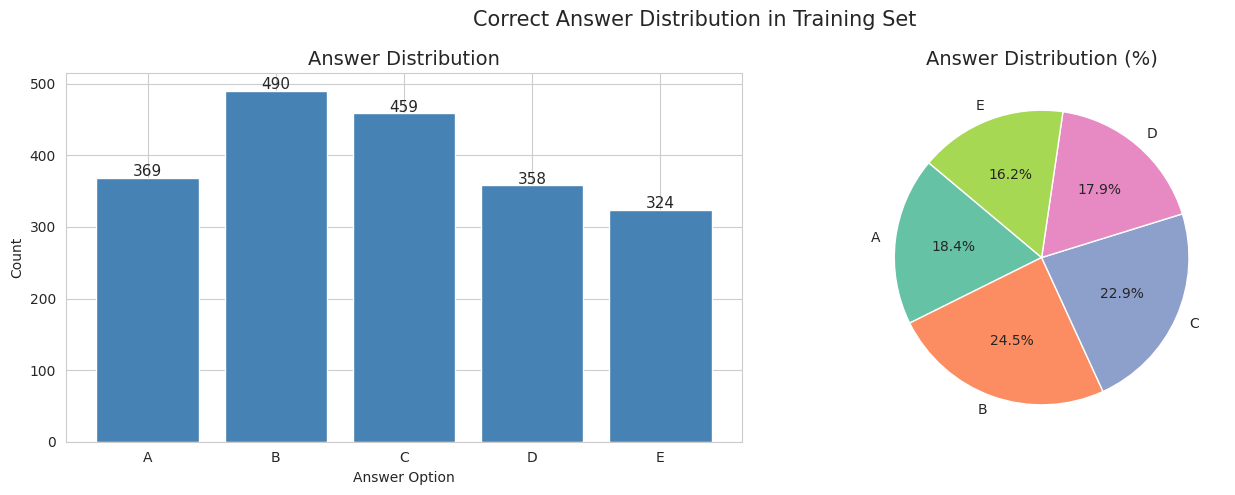


Most frequent answer : B → 490
Least frequent answer: E → 324


In [85]:
answer_counts = train['answer'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(answer_counts.index, answer_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title("Answer Distribution", fontsize=14)
axes[0].set_xlabel("Answer Option")
axes[0].set_ylabel("Count")
for i, v in enumerate(answer_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=11)

# Pie chart
axes[1].pie(answer_counts.values, labels=answer_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette("Set2", 5), startangle=140)
axes[1].set_title("Answer Distribution (%)", fontsize=14)

plt.suptitle("Correct Answer Distribution in Training Set", fontsize=15)
plt.tight_layout()
plt.show()

print("\nMost frequent answer :", answer_counts.idxmax(), "→", answer_counts.max())
print("Least frequent answer:", answer_counts.idxmin(), "→", answer_counts.min())


##  Visualization 2 — Prompt Word Count vs Correct Answer



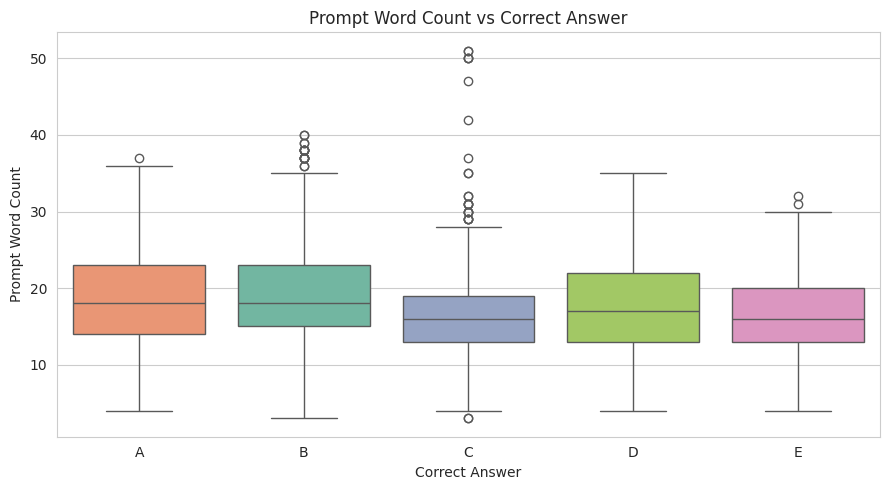

Mean prompt length per answer:
answer
A    19.06
B    19.56
C    17.10
D    17.86
E    16.76
Name: prompt_word_count, dtype: float64


In [86]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='answer', y='prompt_word_count', data=train,
            order=sorted(train['answer'].unique()), palette='Set2',
            hue='answer', legend=False)
plt.title("Prompt Word Count vs Correct Answer")
plt.xlabel("Correct Answer")
plt.ylabel("Prompt Word Count")
plt.tight_layout()
plt.show()

print("Mean prompt length per answer:")
print(train.groupby('answer')['prompt_word_count'].mean().round(2))


# **Baseline Model — TF-IDF + Cosine Similarity**

##  A simple, untrained baseline using TF-IDF vectorization and cosine similarity to rank options by their word-overlap with the prompt. No model learning is involved — this establishes a reference point to compare our trained models against, which are actually learning meaningful patterns, or just matching keywords. 


## TF-IDF Vectorizer 

In [87]:
vectorizer_base = TfidfVectorizer(stop_words='english')
all_texts = []
for _, row in train.iterrows():
    all_texts.append(str(row['prompt']))
    for opt in OPTION_COLS:
        all_texts.append(str(row[opt]))
vectorizer_base.fit(all_texts)
print("Baseline TF-IDF vocabulary size:", len(vectorizer_base.vocabulary_))

Baseline TF-IDF vocabulary size: 2762


## Define MAP@3 Metric and Similarity Ranking Function 

In [88]:
def map_at_3_baseline(ground_truth, predictions):
    score = 0.0
    for k, pred in enumerate(predictions[:3], start=1):
        if pred == ground_truth:
            score = 1.0 / k
            break
    return score


def rank_options_by_similarity(row, vectorizer):
    prompt_vec = vectorizer.transform([str(row['prompt'])])
    sims = {}
    for opt in OPTION_COLS:
        opt_vec = vectorizer.transform([str(row[opt])])
        sims[opt] = cosine_similarity(prompt_vec, opt_vec)[0][0]
    ranked = sorted(sims, key=sims.get, reverse=True)
    return ranked

## Evaluate Baseline Performance (Train MAP@3) 

In [89]:
baseline_scores = []
for _, row in train.iterrows():
    ranked = rank_options_by_similarity(row, vectorizer_base)
    baseline_scores.append(map_at_3_baseline(row['answer'], ranked))

baseline_map3 = np.mean(baseline_scores)
print(f"Baseline (TF-IDF + Cosine Similarity) Train MAP@3: {baseline_map3:.4f}")

Baseline (TF-IDF + Cosine Similarity) Train MAP@3: 0.3119


## Generate Baseline Submission File

In [90]:
baseline_test_preds = []
for _, row in test.iterrows():
    ranked = rank_options_by_similarity(row, vectorizer_base)
    baseline_test_preds.append(' '.join(ranked[:3]))

baseline_submission = pd.DataFrame({
    'ID': test['id'],
    'Prediction': baseline_test_preds
})
baseline_submission.to_csv('submission_baseline.csv', index=False)   
print("Baseline submission saved as submission_baseline.csv")
baseline_submission.head()

Baseline submission saved as submission_baseline.csv


,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A D C
3,4,A E C
4,5,A C E


#  **Model 1 — TF-IDF + Logistic Regression**
## Our first main model — a classical ML approach (the "additional model of choice" category), unlike the untrained baseline Approach: Combine prompt + all 5 options into one text → convert to TF-IDF vectors (unigrams to trigrams) → train a Logistic Regression classifier to predict the correct option → rank predicted probabilities to get top-3 answers for MAP@3. Why it matters: Shows how far a simple, fast, interpretable classical ML model can go using strong TF-IDF features, without any neural network involved.


## W&B Setup

In [91]:
os.environ["WANDB_SILENT"] = "true"

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")

wandb.init(
    project="smart-mcq-solver",
    name="model1-tfidf-logistic",
    config={
        "model"        : "LogisticRegression",
        "max_features" : 100000,
        "ngram_range"  : "(1,3)",
        "C"            : 10.0,
        "max_iter"     : 2000,
        "sublinear_tf" : True
    }
)
print("W&B ready.")


W&B ready.


## Combine Prompt + Options Into Single Text
 

In [92]:
def combine_text(row):
    parts = [str(row['prompt'])] + [str(row[c]) for c in OPTION_COLS]
    return ' '.join(parts)

train['combined'] = train.apply(combine_text, axis=1)
test['combined']  = test.apply(combine_text, axis=1)

print("Text combined.")


Text combined.


## TF-IDF Vectorization

In [93]:
vectorizer = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 3),
    stop_words='english',
    sublinear_tf=True,
    min_df=1,
    analyzer='word'
)

X_train = vectorizer.fit_transform(train['combined'])
X_test  = vectorizer.transform(test['combined'])

le = LabelEncoder()
y_train = le.fit_transform(train['answer'])

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Classes:", le.classes_)


X_train: (2000, 25642)
X_test : (500, 25642)
Classes: ['A' 'B' 'C' 'D' 'E']


## Train Logistic Regression

In [94]:
clf = LogisticRegression(
    max_iter=2000,
    C=10.0,
    solver='lbfgs',
    n_jobs=-1
)

clf.fit(X_train, y_train)
print("Model trained.")


Model trained.


##  Evaluate MAP@3

In [95]:
def map_at_3_logreg(ground_truth, predictions):
    score = 0.0
    for k, pred in enumerate(predictions[:3], start=1):
        if pred == ground_truth:
            score = 1.0 / k
            break
    return score

probs      = clf.predict_proba(X_train)
top3_idx   = np.argsort(probs, axis=1)[:, ::-1][:, :3]
top3_preds = [[le.classes_[i] for i in row] for row in top3_idx]

scores     = [map_at_3_logreg(true, pred) for true, pred in zip(train['answer'], top3_preds)]
train_map3_logreg = np.mean(scores)
print(f"Train MAP@3: {train_map3_logreg:.4f}")

wandb.log({"train_map3": train_map3_logreg})


Train MAP@3: 1.0000


## Generate Logistic Regression Submission file

In [96]:
probs_test = clf.predict_proba(X_test)
top3_idx   = np.argsort(probs_test, axis=1)[:, ::-1][:, :3]
test_preds = [' '.join([le.classes_[i] for i in row]) for row in top3_idx]

submission = pd.DataFrame({
    'ID'         : test['id'],
    'Prediction' : test_preds
})
submission.to_csv('submission_logreg.csv', index=False)
print("Submission created as submission_logreg.csv")
print(submission.head(10))

wandb.finish()


Submission created as submission_logreg.csv
   ID Prediction
0   1      A B E
1   2      B C A
2   3      B C D
3   4      E C B
4   5      C D E
5   6      D C A
6   7      E C B
7   8      B C D
8   9      C B D
9  10      B C D


# **Model 2 — BiLSTM + Attention (Built From Scratch)**

##  Built entirely from scratch — no pretrained weights anywhere. Embeddings, BiLSTM encoder, attention, and scoring head are all trained from random initialization on this competition's data only. 

## New Imports 

In [97]:
import re
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

##  Seed & Device

In [98]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABELS = ["A", "B", "C", "D", "E"]
print("Using device:", DEVICE)

Using device: cuda


## Reuse Already-Loaded Data 

In [99]:
train_df_full = train.copy()
test_df = test.copy()
print("Train shape:", train_df_full.shape)
print("Test shape:", test_df.shape)

Train shape: (2000, 17)
Test shape: (500, 10)


## **Tokenizer & Vocabulary**

## Tokenizer Function  

In [100]:
TOKEN_RE = re.compile(r"[A-Za-z]+|[0-9]+|[^\sA-Za-z0-9]")

def tokenize(text: str):
    text = str(text).lower()
    return TOKEN_RE.findall(text)

## Vocabulary Class 

In [101]:
class Vocab:
    def __init__(self, min_freq=1):
        self.min_freq = min_freq
        self.stoi = {"<pad>": 0, "<unk>": 1}
        self.itos = ["<pad>", "<unk>"]

    def build(self, texts):
        from collections import Counter
        counter = Counter()
        for t in texts:
            counter.update(tokenize(t))
        for word, freq in counter.items():
            if freq >= self.min_freq and word not in self.stoi:
                self.stoi[word] = len(self.itos)
                self.itos.append(word)
        return self

    def encode(self, text, max_len):
        ids = [self.stoi.get(tok, 1) for tok in tokenize(text)][:max_len]
        if len(ids) < max_len:
            ids = ids + [0] * (max_len - len(ids))
        return ids

    def __len__(self):
        return len(self.itos)

## Build Vocabulary 

In [102]:
train_df, val_df = train_test_split(train_df_full, test_size=0.15, random_state=SEED)

text_cols = ["prompt", "A", "B", "C", "D", "E"]
all_texts_scratch = pd.concat([train_df[c] for c in text_cols]).tolist()

vocab = Vocab(min_freq=1).build(all_texts_scratch)
print("Vocabulary size:", len(vocab))

Vocabulary size: 3005


## **Dataset & DataLoader**

##  Dataset Class 

In [103]:
MAX_PROMPT_LEN = 64
MAX_OPT_LEN = 16

class MCQDataset(Dataset):
    def __init__(self, df, vocab, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt_ids = torch.tensor(self.vocab.encode(row["prompt"], MAX_PROMPT_LEN))
        opt_ids = torch.stack([
            torch.tensor(self.vocab.encode(row[l], MAX_OPT_LEN)) for l in LABELS
        ])
        item = {"prompt": prompt_ids, "options": opt_ids}
        if self.has_labels:
            item["label"] = torch.tensor(LABELS.index(row["answer"]))
        else:
            item["id"] = row["id"]
        return item

## Create DataLoaders 

In [104]:
BATCH_SIZE = 32
train_ds = MCQDataset(train_df, vocab)
val_ds = MCQDataset(val_df, vocab)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

## **Model Architecture**

## Model Class 

In [105]:
class ScratchMCQModel(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.encoder = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attn_W = nn.Linear(hidden_dim * 2, hidden_dim * 2, bias=False)
        match_dim = hidden_dim * 2 * 4
        self.scorer = nn.Sequential(
            nn.Linear(match_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def encode(self, x):
        emb = self.embedding(x)
        out, _ = self.encoder(emb)
        return out

    def masked_mean(self, seq, ids):
        mask = (ids != 0).unsqueeze(-1).float()
        summed = (seq * mask).sum(1)
        count = mask.sum(1).clamp(min=1)
        return summed / count

    def forward(self, prompt_ids, option_ids):
        B, num_opts, Lo = option_ids.shape
        prompt_enc = self.encode(prompt_ids)
        prompt_vec = self.masked_mean(prompt_enc, prompt_ids)

        scores = []
        for i in range(num_opts):
            opt_ids_i = option_ids[:, i, :]
            opt_enc = self.encode(opt_ids_i)
            opt_vec = self.masked_mean(opt_enc, opt_ids_i)

            attn_scores = torch.bmm(self.attn_W(prompt_enc), opt_vec.unsqueeze(-1)).squeeze(-1)
            pad_mask = (prompt_ids == 0)
            attn_scores = attn_scores.masked_fill(pad_mask, -1e9)
            attn_weights = F.softmax(attn_scores, dim=-1).unsqueeze(-1)
            prompt_ctx = (attn_weights * prompt_enc).sum(1)

            diff = torch.abs(opt_vec - prompt_ctx)
            prod = opt_vec * prompt_ctx
            match_vec = torch.cat([opt_vec, prompt_ctx, diff, prod], dim=-1)
            score_i = self.scorer(match_vec).squeeze(-1)
            scores.append(score_i)

        return torch.stack(scores, dim=1)

## Initialize Model 

In [106]:
model = ScratchMCQModel(vocab_size=len(vocab)).to(DEVICE)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")

Trainable parameters: 845,697


## MAP@3 Function

In [107]:
def map_at_3_scratch(logits, labels):
    top3 = torch.topk(logits, k=3, dim=-1).indices
    scores = []
    for pred, true in zip(top3.tolist(), labels.tolist()):
        if true in pred:
            rank = pred.index(true) + 1
            scores.append(1.0 / rank)
        else:
            scores.append(0.0)
    return sum(scores) / len(scores)

## Accuracy & F1 Function 

In [108]:
def accuracy_f1(logits, labels):
    preds = torch.argmax(logits, dim=-1).cpu().numpy()
    labels_np = labels.cpu().numpy()
    return (
        accuracy_score(labels_np, preds),
        f1_score(labels_np, preds, average="macro"),
    )

## Train & Eval Loop Function 

In [109]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_logits, all_labels = 0.0, [], []
    for batch in loader:
        prompt = batch["prompt"].to(DEVICE)
        options = batch["options"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(prompt, options)
            loss = F.cross_entropy(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

        total_loss += loss.item() * prompt.size(0)
        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.detach().cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    acc, f1 = accuracy_f1(all_logits, all_labels)
    map3 = map_at_3_scratch(all_logits, all_labels)
    return total_loss / len(loader.dataset), acc, f1, map3

## **Training**

## W&B Init

In [110]:
os.environ["WANDB_SILENT"] = "true"

wandb.init(
    project="smart-mcq-solver",
    name="model2-scratch-bilstm-attn",
    config={
        "emb_dim": 128, "hidden_dim": 128, "lr": 1e-3,
        "batch_size": BATCH_SIZE, "epochs": 15,
        "model_type": "from_scratch_bilstm_attention",
    },
)

## Training Loop 

In [111]:
EPOCHS = 15
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
best_map3 = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1, tr_map3 = run_epoch(model, train_loader, optimizer)
    val_loss, val_acc, val_f1, val_map3 = run_epoch(model, val_loader)

    print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} map3={tr_map3:.4f} | "
          f"val_loss={val_loss:.4f} val_map3={val_map3:.4f}")

    wandb.log({
        "epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc,
        "train_f1": tr_f1, "train_map3": tr_map3,
        "val_loss": val_loss, "val_acc": val_acc,
        "val_f1": val_f1, "val_map3": val_map3,
    })

    if val_map3 > best_map3:
        best_map3 = val_map3
        torch.save({"model_state": model.state_dict(), "vocab_stoi": vocab.stoi},
                   "scratch_model_best.pt")

wandb.finish()
print("Best validation MAP@3:", best_map3)

Epoch 01 | train_loss=1.2478 map3=0.6424 | val_loss=0.5694 val_map3=0.8356
Epoch 02 | train_loss=0.4119 map3=0.8791 | val_loss=0.2515 val_map3=0.9000
Epoch 03 | train_loss=0.2879 map3=0.8987 | val_loss=0.2404 val_map3=0.8978
Epoch 04 | train_loss=0.2696 map3=0.9036 | val_loss=0.2315 val_map3=0.8967
Epoch 05 | train_loss=0.2666 map3=0.9126 | val_loss=0.2312 val_map3=0.9033
Epoch 06 | train_loss=0.2671 map3=0.9040 | val_loss=0.2331 val_map3=0.8967
Epoch 07 | train_loss=0.2669 map3=0.9038 | val_loss=0.2292 val_map3=0.8989
Epoch 08 | train_loss=0.2588 map3=0.9064 | val_loss=0.2303 val_map3=0.8967
Epoch 09 | train_loss=0.2527 map3=0.9137 | val_loss=0.2290 val_map3=0.9006
Epoch 10 | train_loss=0.2633 map3=0.9090 | val_loss=0.2306 val_map3=0.9006
Epoch 11 | train_loss=0.2595 map3=0.9024 | val_loss=0.2279 val_map3=0.8989
Epoch 12 | train_loss=0.2494 map3=0.9086 | val_loss=0.2260 val_map3=0.9000
Epoch 13 | train_loss=0.2582 map3=0.9107 | val_loss=0.2302 val_map3=0.9028
Epoch 14 | train_loss=0.2

## **Inference & Submission**

## Load Best Checkpoint

In [112]:
checkpoint = torch.load("scratch_model_best.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])

<All keys matched successfully>

## Test Dataset Class 

In [113]:
class MCQTestDataset(Dataset):
    def __init__(self, df, vocab):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt_ids = torch.tensor(self.vocab.encode(row["prompt"], MAX_PROMPT_LEN))
        opt_ids = torch.stack([
            torch.tensor(self.vocab.encode(row[l], MAX_OPT_LEN)) for l in LABELS
        ])
        return {"id": row["id"], "prompt": prompt_ids, "options": opt_ids}

test_ds = MCQTestDataset(test_df, vocab)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

## Run Inference 

In [114]:
model.eval()
ids_all, preds_all = [], []
with torch.no_grad():
    for batch in test_loader:
        prompt = batch["prompt"].to(DEVICE)
        options = batch["options"].to(DEVICE)
        logits = model(prompt, options)
        top3 = torch.topk(logits, k=3, dim=-1).indices.cpu().numpy()
        preds_all.extend([" ".join(LABELS[i] for i in row) for row in top3])
        ids_all.extend(batch["id"].numpy())

## Generate Scratch Model Submission file

In [115]:
submission_scratch = pd.DataFrame({"ID": ids_all, "Prediction": preds_all})
submission_scratch.to_csv("submission_scratch.csv", index=False)
print("Submission saved: submission_scratch.csv")
submission_scratch.head()

Submission saved: submission_scratch.csv


,ID,Prediction
0,1,A C B
1,2,B E D
2,3,B A E
3,4,E C A
4,5,C B A


# **Model 3 — ELECTRA-base-discriminator (Pretrained, Fine-Tuned)**

## Our third main model — a **pretrained transformer**, fine-tuned using Hugging Face Transformers' `AutoModelForMultipleChoice`, treating each question as a 5-way multiple-choice classification problem.

## Setup 

In [116]:
!pip install transformers -q

from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForMultipleChoice
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

import os
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

import warnings
warnings.filterwarnings('ignore')

from transformers import logging
logging.set_verbosity_error()

import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

print("PyTorch:", torch.__version__)
print("CUDA   :", torch.cuda.is_available())

PyTorch: 2.10.0+cu128
CUDA   : True


## Configuration 

In [117]:
MODEL_NAME_E  = "google/electra-base-discriminator"
MAX_LEN_E     = 128
BATCH_SIZE_E  = 16
EPOCHS_E      = 3
LR_E          = 3e-5
VAL_SIZE_E    = 0.1

print("Device:", DEVICE)
print("Model :", MODEL_NAME_E)

Device: cuda
Model : google/electra-base-discriminator


## Reuse Already-Loaded Data 

In [118]:
train_e = train.copy()
test_e  = test.copy()

print("Train:", train_e.shape)
print("Test :", test_e.shape)

Train: (2000, 17)
Test : (500, 10)


## Train & Validation Split

In [119]:
torch.manual_seed(SEED)
np.random.seed(SEED)

train_df_e, val_df_e = train_test_split(
    train_e, test_size=VAL_SIZE_E, random_state=SEED, stratify=train_e['answer']
)
train_df_e = train_df_e.reset_index(drop=True)
val_df_e   = val_df_e.reset_index(drop=True)

print("Train:", train_df_e.shape)
print("Val  :", val_df_e.shape)

Train: (1800, 17)
Val  : (200, 17)


## MAP@3 Utility 

In [120]:
def map_at_3_electra(ground_truth, predictions):
    score = 0.0
    for k, pred in enumerate(predictions[:3], start=1):
        if pred == ground_truth:
            score = 1.0 / k
            break
    return score

def evaluate_map3_electra(df, pred_col='prediction'):
    scores = []
    for _, row in df.iterrows():
        preds = row[pred_col].split()
        scores.append(map_at_3_electra(row['answer'], preds))
    return np.mean(scores)

print("MAP@3 ready.")

MAP@3 ready.


# **Dataset Preparation**

## Tokenizer + Dataset Class

In [121]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_E)

class ElectraMCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128, is_test=False):
        self.df      = df.reset_index(drop=True)
        self.tok     = tokenizer
        self.max_len = max_len
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        prompt  = str(row['prompt'])
        options = [str(row[c]) for c in OPTION_COLS]

        encodings = []
        for opt in options:
            enc = self.tok(
                prompt, opt,
                max_length=self.max_len,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            encodings.append(enc)

        input_ids      = torch.cat([e['input_ids'] for e in encodings], dim=0)
        attention_mask = torch.cat([e['attention_mask'] for e in encodings], dim=0)
        out = {'input_ids': input_ids, 'attention_mask': attention_mask}

        if not self.is_test:
            out['labels'] = torch.tensor(OPTION_COLS.index(row['answer']), dtype=torch.long)
        return out

## Create Datasets & Loaders 

In [122]:
train_dataset_e = ElectraMCQDataset(train_df_e, tokenizer, MAX_LEN_E)
val_dataset_e   = ElectraMCQDataset(val_df_e,   tokenizer, MAX_LEN_E)
test_dataset_e  = ElectraMCQDataset(test_e,     tokenizer, MAX_LEN_E, is_test=True)

train_loader_e = DataLoader(train_dataset_e, batch_size=BATCH_SIZE_E, shuffle=True,  num_workers=2)
val_loader_e   = DataLoader(val_dataset_e,   batch_size=BATCH_SIZE_E, shuffle=False, num_workers=2)
test_loader_e  = DataLoader(test_dataset_e,  batch_size=BATCH_SIZE_E, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader_e))
print("Val batches  :", len(val_loader_e))

Train batches: 113
Val batches  : 13


## Load Pretrained Model 

In [123]:
electra_model = AutoModelForMultipleChoice.from_pretrained(MODEL_NAME_E)
electra_model = electra_model.to(DEVICE)
print("Model loaded:", MODEL_NAME_E)
print("Parameters  :", sum(p.numel() for p in electra_model.parameters()) // 1_000_000, "M")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Model loaded: google/electra-base-discriminator
Parameters  : 109 M


## W&B Setup 

In [124]:
os.environ["WANDB_SILENT"] = "true"

wandb.init(
    project="smart-mcq-solver",
    name="model3-electra-base",
    config={
        "model_name" : MODEL_NAME_E,
        "max_len"    : MAX_LEN_E,
        "batch_size" : BATCH_SIZE_E,
        "epochs"     : EPOCHS_E,
        "lr"         : LR_E
    }
)

# **Training** 
## Optimizer & Scheduler Setup

In [125]:
optimizer_e = AdamW(electra_model.parameters(), lr=LR_E, weight_decay=0.01)
total_steps = len(train_loader_e) * EPOCHS_E
scheduler_e = get_linear_schedule_with_warmup(
    optimizer_e,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

best_map3_e  = 0.0
best_epoch_e = 0

## Training Loop  

In [126]:
for epoch in range(1, EPOCHS_E + 1):

    electra_model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, batch in enumerate(train_loader_e):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        outputs = electra_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        logits  = outputs.logits

        loss.backward()
        nn.utils.clip_grad_norm_(electra_model.parameters(), 1.0)
        optimizer_e.step()
        scheduler_e.step()
        optimizer_e.zero_grad()

        preds    = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        total_loss += loss.item()

        if (batch_idx + 1) % 20 == 0:
            print(f"  Epoch {epoch} | Batch {batch_idx + 1}/{len(train_loader_e)} | Loss so far: {total_loss / (batch_idx + 1):.4f}")

    train_acc  = correct / total
    train_loss = total_loss / len(train_loader_e)

    electra_model.eval()
    val_preds = []

    with torch.no_grad():
        for batch in val_loader_e:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            outputs        = electra_model(input_ids=input_ids, attention_mask=attention_mask)
            logits         = outputs.logits
            top3           = logits.argsort(dim=-1, descending=True)[:, :3]
            for row in top3:
                val_preds.append(' '.join([OPTION_COLS[i] for i in row.cpu().numpy()]))

    val_df_e['prediction'] = val_preds
    val_map3 = evaluate_map3_electra(val_df_e)

    print(f"Epoch {epoch} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Val MAP@3: {val_map3:.4f}")

    wandb.log({
        "epoch"      : epoch,
        "train_loss" : round(train_loss, 5),
        "train_acc"  : round(train_acc,  5),
        "val_map3"   : round(val_map3,   5)
    })

    if val_map3 > best_map3_e:
        best_map3_e  = val_map3
        best_epoch_e = epoch
        print(f"Best epoch: {epoch} | MAP@3: {val_map3:.4f}")

print(f"Best Val MAP@3: {best_map3_e:.4f} at epoch {best_epoch_e}")
wandb.log({"best_val_map3": best_map3_e, "best_epoch": best_epoch_e})

  Epoch 1 | Batch 20/113 | Loss so far: 1.6085
  Epoch 1 | Batch 40/113 | Loss so far: 1.5902
  Epoch 1 | Batch 60/113 | Loss so far: 1.5349
  Epoch 1 | Batch 80/113 | Loss so far: 1.4449
  Epoch 1 | Batch 100/113 | Loss so far: 1.3494
Epoch 1 | Loss: 1.2999 | Acc: 0.5094 | Val MAP@3: 0.9258
Best epoch: 1 | MAP@3: 0.9258
  Epoch 2 | Batch 20/113 | Loss so far: 0.6422
  Epoch 2 | Batch 40/113 | Loss so far: 0.5856
  Epoch 2 | Batch 60/113 | Loss so far: 0.5330
  Epoch 2 | Batch 80/113 | Loss so far: 0.4870
  Epoch 2 | Batch 100/113 | Loss so far: 0.4479
Epoch 2 | Loss: 0.4410 | Acc: 0.8622 | Val MAP@3: 0.9975
Best epoch: 2 | MAP@3: 0.9975
  Epoch 3 | Batch 20/113 | Loss so far: 0.2441
  Epoch 3 | Batch 40/113 | Loss so far: 0.2186
  Epoch 3 | Batch 60/113 | Loss so far: 0.2049
  Epoch 3 | Batch 80/113 | Loss so far: 0.1998
  Epoch 3 | Batch 100/113 | Loss so far: 0.1899
Epoch 3 | Loss: 0.1936 | Acc: 0.9389 | Val MAP@3: 0.9975
Best Val MAP@3: 0.9975 at epoch 2


## Test Inference

In [127]:
electra_model.eval()
test_preds_e = []

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader_e):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        outputs        = electra_model(input_ids=input_ids, attention_mask=attention_mask)
        logits         = outputs.logits
        top3           = logits.argsort(dim=-1, descending=True)[:, :3]
        for row in top3:
            test_preds_e.append(' '.join([OPTION_COLS[i] for i in row.cpu().numpy()]))

        if (batch_idx + 1) % 10 == 0:
            print(f"Processed batch {batch_idx + 1}/{len(test_loader_e)}")

print("Test inference complete.")

Processed batch 10/32
Processed batch 20/32
Processed batch 30/32
Test inference complete.


## Generate ELECTRA-base Submission file

In [128]:
submission_electra = pd.DataFrame({
    'ID'         : test_e['id'],
    'Prediction' : test_preds_e
})

submission_electra.to_csv('submission.csv', index=False)
print("Submission created.")
print(submission_electra.head(10))

wandb.finish()

Submission created.
   ID Prediction
0   1      A D C
1   2      B D C
2   3      B E D
3   4      E C D
4   5      C A D
5   6      D A E
6   7      E D C
7   8      B C E
8   9      C D E
9  10      B E C


# **Model Comparison**

##  Summary of all approaches tried in this project. The three **main models** were submitted to Kaggle and scored on the competition leaderboard; the baseline was evaluated locally (train MAP@3) for reference.

## Build Comparison Table

In [129]:
comparison_data = {
    "Model": [
        "Baseline: TF-IDF + Cosine Similarity",
        "TF-IDF + Logistic Regression",
        "BiLSTM + Attention (From Scratch)",
        "ELECTRA-base-discriminator (Pretrained)",
    ],
    "Category": [
        "Unsupervised baseline",
        "Classical ML (main model)",
        "From scratch (main model, no pretrained weights)",
        "Pretrained transformer (main model, fine-tuned)",
    ],
    "Evaluation": [
        "Train MAP@3 (local)",
        "Kaggle MAP@3 (leaderboard)",
        "Kaggle MAP@3 (leaderboard)",
        "Kaggle MAP@3 (leaderboard)",
    ],
    "MAP@3 Score": [
        baseline_map3,
        0.73815,
        0.71238,
        0.75519,
    ],
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values("MAP@3 Score", ascending=False).reset_index(drop=True)
comparison_df

,Model,Category,Evaluation,MAP@3 Score
0,ELECTRA-base-discriminator (Pretrained),"Pretrained transformer (main model, fine-tuned)",Kaggle MAP@3 (leaderboard),0.755190
1,TF-IDF + Logistic Regression,Classical ML (main model),Kaggle MAP@3 (leaderboard),0.738150
2,BiLSTM + Attention (From Scratch),"From scratch (main model, no pretrained weights)",Kaggle MAP@3 (leaderboard),0.712380
3,Baseline: TF-IDF + Cosine Similarity,Unsupervised baseline,Train MAP@3 (local),0.311917


## Visualize Comparison 

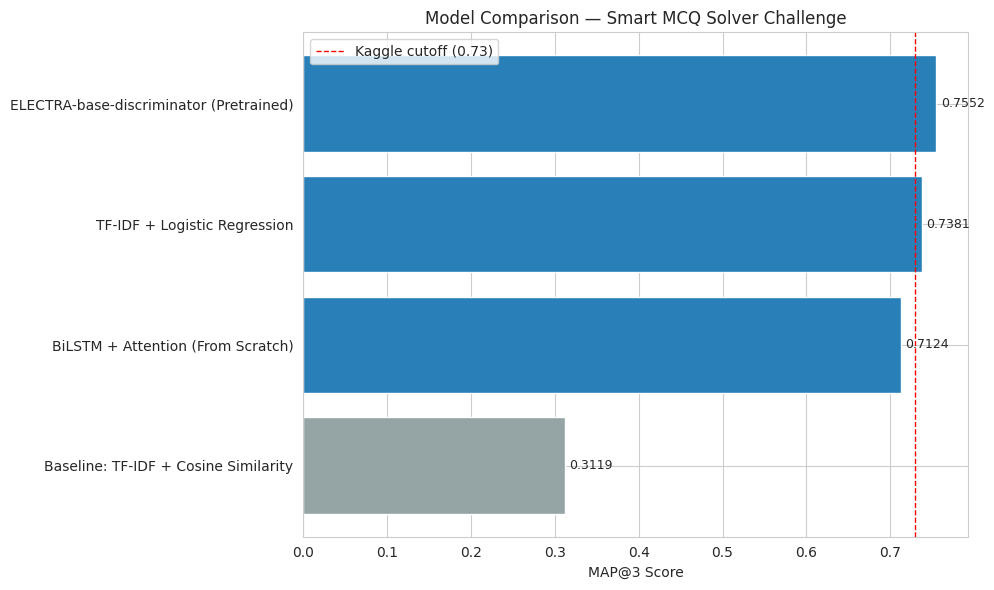

In [130]:
plt.figure(figsize=(10, 6))
colors = ['#95a5a6' if 'local' in e else '#2980b9' for e in comparison_df['Evaluation']]
bars = plt.barh(comparison_df['Model'], comparison_df['MAP@3 Score'], color=colors)
plt.xlabel("MAP@3 Score")
plt.title("Model Comparison — Smart MCQ Solver Challenge")
plt.gca().invert_yaxis()
for bar, score in zip(bars, comparison_df['MAP@3 Score']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
              f"{score:.4f}", va='center', fontsize=9)
plt.axvline(0.73, color='red', linestyle='--', linewidth=1, label='Kaggle cutoff (0.73)')
plt.legend()
plt.tight_layout()
plt.show()

# **Summary** 



## Three unique models were built and compared: **Logistic Regression** (0.73815), **BiLSTM + Attention from scratch** (0.71238), and **ELECTRA-base-discriminator** (0.75519).

## **ELECTRA** performed best, showing the strength of a pretrained transformer fine-tuned on this task.

## **Logistic Regression** also crossed the Kaggle qualifying cutoff (0.73), proving a simple classical ML model can perform well with strong TF-IDF features.

## The **from-scratch model** scored close to the cutoff (0.71238) without using any pretrained knowledge a solid result given it learns everything from this dataset alone.

## The **TF-IDF + Cosine Similarity baseline** scored much lower (~0.31), confirming that our trained models are learning real patterns, not just keyword matching.
